# Step 4 - Sparse method with Haar wavelets and Matching Pursuit

This notebook implements the **sparse method** part of the project using the notation from exercise sheet 9.

The imaging model is

$$
g_{true} = h \otimes f_{true} = A f_{true},
$$

and the noisy observation is

$$
g' = g_{true} + \epsilon.
$$

Notation:

- $f_{true}$: clean image/signal,
- $h$ / `A_psf`: point-spread function,
- $A$: blur operator,
- $g'$ / `gn`: noisy observed image,
- $\Psi$: Haar wavelet transform,
- $s$: sparse Haar coefficient representation,
- $\Phi = A\Psi$: blurred Haar dictionary.

This version uses the **original full 512 x 512 image size**, but converts RGB images to grayscale/luminance for computational feasibility.


## 1. Why full-size grayscale?

Full RGB Matching Pursuit is too slow for this notebook. The number of possible Haar atoms is

$$
512 \times 512 \times 3 = 786432.
$$

For grayscale, the number is

$$
512 \times 512 = 262144.
$$

That is still large, but about three times smaller. It also avoids choosing separate atoms for each color channel.

So the compromise is:

- keep the **original full image size**;
- use **grayscale/luminance** instead of RGB;
- use `A_2`, the horizontal row-wise zero-padding operator, as the main sparse method;
- keep `A_1` only as an optional single-case comparison.


## 2. Matching Pursuit idea

The sparse model is

$$
f = \Psi s,
$$

so

$$
g' = A f + \epsilon = A\Psi s + \epsilon = \Phi s + \epsilon.
$$

Matching Pursuit greedily selects one Haar atom at a time. At iteration $i$, it chooses the atom most correlated with the residual:

$$
k^{(i)} = \arg\max_k \langle r^{(i)}, \tilde{\Phi}_k \rangle^2.
$$

This is called greedy because it makes the best local choice at each step, instead of solving a global combinatorial sparse recovery problem.


In [24]:
# 3. Imports and project paths

from __future__ import annotations

import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.signal import convolve2d


def find_project_root() -> Path:
    """Find the repository root by looking for AGENTS.md and docs/project_plan.md."""
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "docs" / "project_plan.md").exists():
            return candidate
    raise FileNotFoundError("Could not find project root. Launch Jupyter inside this repository.")


PROJECT_ROOT = find_project_root()
DATA_CLEAN_DIR = PROJECT_ROOT / "data" / "processed" / "clean"
RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "sparse_matching_pursuit"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Clean images:", DATA_CLEAN_DIR)
print("Results directory:", RESULTS_DIR)


Project root: /Users/giannigagliardi/localDocuments/gitLocal/Photodeblurring_IPProject
Clean images: /Users/giannigagliardi/localDocuments/gitLocal/Photodeblurring_IPProject/data/processed/clean
Results directory: /Users/giannigagliardi/localDocuments/gitLocal/Photodeblurring_IPProject/data/results/sparse_matching_pursuit


In [25]:
# 4. Image loading/saving helpers


def load_rgb_float(path: Path) -> np.ndarray:
    """Load an RGB image as float array in [0, 1]."""
    return np.asarray(Image.open(path).convert("RGB"), dtype=np.float32) / 255.0


def rgb_to_luminance(image: np.ndarray) -> np.ndarray:
    """Convert RGB image to grayscale/luminance using Rec. 601 weights."""
    return (0.299 * image[..., 0] + 0.587 * image[..., 1] + 0.114 * image[..., 2]).astype(np.float64)


def load_gray_float(path: Path) -> np.ndarray:
    """Load an image and convert it to grayscale/luminance in [0, 1]."""
    return rgb_to_luminance(load_rgb_float(path))


def save_gray_float(path: Path, image: np.ndarray) -> None:
    """Save a grayscale float image in [0, 1] as PNG."""
    path.parent.mkdir(parents=True, exist_ok=True)
    image_uint8 = (np.clip(image, 0, 1) * 255.0 + 0.5).astype(np.uint8)
    Image.fromarray(image_uint8, mode="L").save(path)


clean_paths = {path.stem: path for path in sorted(DATA_CLEAN_DIR.glob("*.png"))}
if not clean_paths:
    raise FileNotFoundError(f"No clean images found in {DATA_CLEAN_DIR}")

for clean_id, path in clean_paths.items():
    image = load_gray_float(path)
    print(f"image {clean_id}: {path.name}, grayscale shape={image.shape}, range=({image.min():.3f}, {image.max():.3f})")


image 1: 1.png, grayscale shape=(512, 512), range=(0.000, 0.890)
image 2: 2.png, grayscale shape=(512, 512), range=(0.000, 1.000)
image 3: 3.png, grayscale shape=(512, 512), range=(0.018, 1.000)


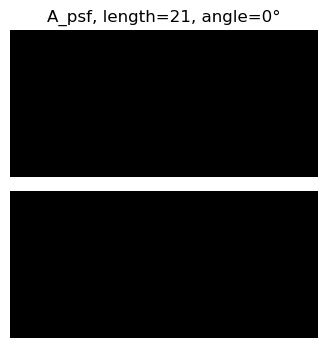

In [26]:
# 5. Blur operators A_1 and A_2 for full-size grayscale images

BLUR_LENGTH = 21
BLUR_ANGLE_DEG = 0


def motion_blur_psf(length: int, angle_deg: float) -> np.ndarray:
    """Create a normalized linear motion-blur PSF."""
    size = int(length)
    if size % 2 == 0:
        size += 1
    psf = np.zeros((size, size), dtype=np.float64)
    center = size // 2
    angle_rad = np.deg2rad(angle_deg)
    t = np.linspace(-(length - 1) / 2, (length - 1) / 2, length)
    x = np.rint(center + t * np.cos(angle_rad)).astype(int)
    y = np.rint(center + t * np.sin(angle_rad)).astype(int)
    valid = (x >= 0) & (x < size) & (y >= 0) & (y < size)
    psf[y[valid], x[valid]] = 1.0
    psf /= psf.sum()
    return psf


A_psf = motion_blur_psf(BLUR_LENGTH, BLUR_ANGLE_DEG)


def apply_A_1_gray(image: np.ndarray) -> np.ndarray:
    """A_1: 2D convolution with zero padding in both dimensions."""
    return convolve2d(image, A_psf, mode="same", boundary="fill", fillvalue=0.0)


def apply_A_1_adjoint_gray(image: np.ndarray) -> np.ndarray:
    """Adjoint of A_1 using the flipped kernel."""
    return convolve2d(image, np.flipud(np.fliplr(A_psf)), mode="same", boundary="fill", fillvalue=0.0)


def horizontal_kernel_from_psf(psf: np.ndarray) -> np.ndarray:
    """Extract the nonzero horizontal row of a horizontal motion PSF."""
    row_index = int(np.argmax(np.sum(np.abs(psf), axis=1)))
    kernel = psf[row_index, :].astype(np.float64)
    if kernel.sum() != 0:
        kernel = kernel / kernel.sum()
    return kernel


A_kernel_1d = horizontal_kernel_from_psf(A_psf)


def apply_A_2_gray(image: np.ndarray) -> np.ndarray:
    """A_2: row-wise horizontal convolution with zero padding in columns."""
    output = np.zeros_like(image, dtype=np.float64)
    for row in range(image.shape[0]):
        output[row, :] = np.convolve(image[row, :], A_kernel_1d, mode="same")
    return output


def apply_A_2_adjoint_gray(image: np.ndarray) -> np.ndarray:
    """Adjoint of A_2 using the flipped 1D kernel."""
    kernel = A_kernel_1d[::-1]
    output = np.zeros_like(image, dtype=np.float64)
    for row in range(image.shape[0]):
        output[row, :] = np.convolve(image[row, :], kernel, mode="same")
    return output


plt.figure(figsize=(4, 4))
plt.imshow(A_psf, cmap="gray")
plt.title(f"A_psf, length={BLUR_LENGTH}, angle={BLUR_ANGLE_DEG}°")
plt.axis("off")
plt.show()


## 3. Fast Haar transform for full-size grayscale images

We use the same orthonormal Haar transform $\Psi$ as in the exercise, but implemented recursively instead of as a dense matrix multiplication. This makes full 512 x 512 grayscale Matching Pursuit feasible enough for experimentation.


In [27]:
# 6. Fast orthonormal Haar transform

SQRT2 = np.sqrt(2.0)


# Earlier we constructed the Haar transformation matrix Psi explicitly and computed
#
#     s = Psi @ f @ Psi.T
#
# This is mathematically simple but inefficient for large images because Psi is a
# dense N x N matrix.
#
# These functions compute exactly the same Haar transform without ever constructing
# Psi explicitly. Instead, they repeatedly combine neighboring samples into
# averages (low-frequency information) and differences (high-frequency details).
#
# This recursive algorithm has much lower computational cost than multiplying by
# the full transformation matrix.

def haar1d_forward_axis(array: np.ndarray, axis: int) -> np.ndarray:
    """
    Fast orthonormal Haar transform along one axis.
    Instead of multiplying by the Haar matrix Psi, this function recursively
    computes:

        - averages  (low-frequency / smooth information)
        - differences (high-frequency / edge information)

    At each level, neighboring values are paired together:

        [x1, x2]  -->  average, difference

    The averages are transformed again at the next level, while the differences
    are already final Haar coefficients.
    """

    output = np.moveaxis(array.astype(np.float64, copy=True), axis, 0)
    n = output.shape[0]
    if n < 1 or (n & (n - 1)) != 0:
        raise ValueError("Haar transform size must be a power of two.")
    h = n
    while h > 1:
        part = output[:h].copy()
        avg = (part[0:h:2] + part[1:h:2]) / SQRT2
        diff = (part[0:h:2] - part[1:h:2]) / SQRT2
        output[:h // 2] = avg
        output[h // 2:h] = diff
        h //= 2
    return np.moveaxis(output, 0, axis)


def haar1d_inverse_axis(coeffs: np.ndarray, axis: int) -> np.ndarray:
    """
    Inverse fast orthonormal Haar transform along one axis.
    Reconstructs the original signal by reversing the forward transform.

    Starting from the coarsest approximation, the algorithm repeatedly combines

        average + difference

    to recover the original neighboring values.
    """
    output = np.moveaxis(coeffs.astype(np.float64, copy=True), axis, 0)
    n = output.shape[0]
    h = 1
    while h < n:
        part = output[:2 * h].copy()
        avg = part[:h]
        diff = part[h:2 * h]
        output[0:2 * h:2] = (avg + diff) / SQRT2
        output[1:2 * h:2] = (avg - diff) / SQRT2
        h *= 2
    return np.moveaxis(output, 0, axis)


def haar2_gray(image: np.ndarray) -> np.ndarray:
    """2D Haar transform for a grayscale image."""
    coeffs = haar1d_forward_axis(image, axis=0)
    coeffs = haar1d_forward_axis(coeffs, axis=1)
    return coeffs


def inverse_haar2_gray(coeffs: np.ndarray) -> np.ndarray:
    """Inverse 2D Haar transform for grayscale coefficient arrays."""
    image = haar1d_inverse_axis(coeffs, axis=1)
    image = haar1d_inverse_axis(image, axis=0)
    return image


f_test = load_gray_float(clean_paths[sorted(clean_paths)[0]])
s_test = haar2_gray(f_test)
f_test_back = inverse_haar2_gray(s_test)
print("Fast Haar reconstruction error:", np.max(np.abs(f_test - f_test_back)))
print("Coefficient shape:", s_test.shape)


Fast Haar reconstruction error: 2.6645352591003757e-15
Coefficient shape: (512, 512)


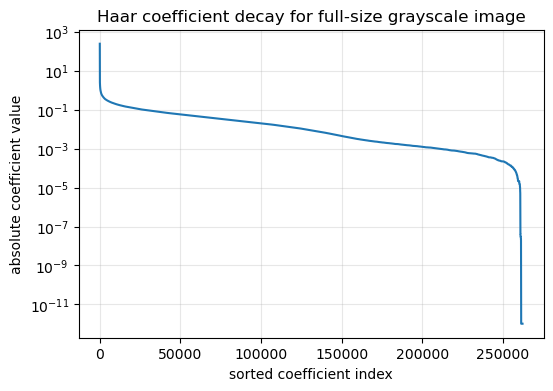

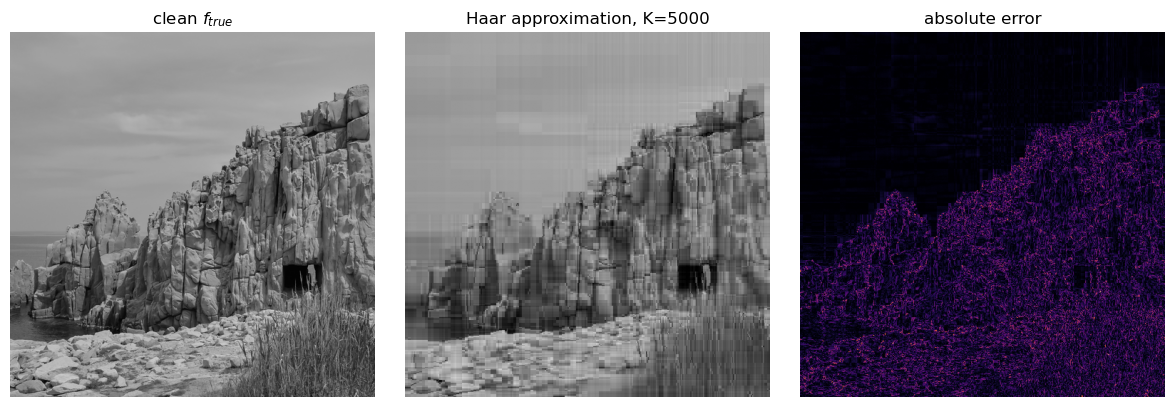

In [28]:
# 7. Sparse coefficient decay on one full-size grayscale image

f_true_demo = load_gray_float(clean_paths["1"] if "1" in clean_paths else sorted(clean_paths.values())[0])
s_true = haar2_gray(f_true_demo)
abs_coeffs = np.sort(np.abs(s_true).ravel())[::-1]

plt.figure(figsize=(6, 4))
plt.semilogy(abs_coeffs + 1e-12)
plt.xlabel("sorted coefficient index")
plt.ylabel("absolute coefficient value")
plt.title("Haar coefficient decay for full-size grayscale image")
plt.grid(True, which="both", alpha=0.3)
plt.show()

K_KEEP = 5000
threshold = abs_coeffs[K_KEEP - 1]
s_sparse_demo = s_true * (np.abs(s_true) >= threshold)
f_sparse_demo = inverse_haar2_gray(s_sparse_demo)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(f_true_demo, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("clean $f_{true}$")
axes[0].axis("off")
axes[1].imshow(np.clip(f_sparse_demo, 0, 1), cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Haar approximation, K={K_KEEP}")
axes[1].axis("off")
axes[2].imshow(np.abs(f_true_demo - f_sparse_demo), cmap="inferno")
axes[2].set_title("absolute error")
axes[2].axis("off")
plt.tight_layout()
plt.show()


## 4. Full-size grayscale Matching Pursuit

The main operator is `A_2`, because the blur is horizontal and `A_2` is the row-wise model from the exercise. `A_1` is kept as an optional single-case comparison, but not used for all cases by default.


In [ ]:
# 8. Matching Pursuit for full-size grayscale images
# We now solve the sparse inverse problem:
#
#     g_n ≈ A f
#
# with the Haar representation
#
#     f = Psi s.
#
# Substituting gives:
#
#     g_n ≈ A Psi s = Phi s.
#
# Matching Pursuit estimates the sparse coefficient array s
# by repeatedly selecting the atom that best matches the current residual.


def make_operator(forward, adjoint, name: str) -> dict:
    """Package a forward blur operator and its adjoint."""
    return {"forward": forward, "adjoint": adjoint, "name": name}


A_1_operator = make_operator(apply_A_1_gray, apply_A_1_adjoint_gray, "A_1: zero padding in both dimensions")
A_2_operator = make_operator(apply_A_2_gray, apply_A_2_adjoint_gray, "A_2: zero padding in one dimension")


def haar_atom_gray(index: tuple[int, int], shape: tuple[int, int]) -> np.ndarray:
    """Construct one grayscale Haar basis image from a coefficient index."""
    coeffs = np.zeros(shape, dtype=np.float64)
    coeffs[index] = 1.0
    return inverse_haar2_gray(coeffs)


def solve_matching_pursuit_gray(A: dict, gn: np.ndarray, n: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Greedy Matching Pursuit for a full-size grayscale observation gn."""
    f_est = np.zeros_like(gn, dtype=np.float64)
    s_est = np.zeros_like(gn, dtype=np.float64)

    residual = -gn.astype(np.float64).copy()
    list_r_norm = [float(np.linalg.norm(residual))]

    for iteration in range(n):
        # Correlations with all atoms: Phi^T r = Psi^T A^T r.
        adjoint_residual = A["adjoint"](residual)
        correlations = haar2_gray(adjoint_residual)
        atom_index = np.unravel_index(int(np.argmax(np.abs(correlations))), correlations.shape)

        psi_k = haar_atom_gray(atom_index, gn.shape)
        phi_k = A["forward"](psi_k)

        phi_norm_sq = float(np.sum(phi_k * phi_k))
        if phi_norm_sq <= 1e-14:
            print("Stopping early because selected atom has nearly zero norm.")
            break

        corr = float(np.sum(residual * phi_k))
        beta = -corr / phi_norm_sq

        f_est = f_est + beta * psi_k
        s_est[atom_index] += beta
        residual = residual + beta * phi_k
        list_r_norm.append(float(np.linalg.norm(residual)))

        if (iteration + 1) % 100 == 0:
            print(f"{A['name']} | iteration {iteration + 1:4d}/{n}: ||r|| = {list_r_norm[-1]:.6f}")

    return f_est, np.asarray(list_r_norm), s_est


print("Full-size grayscale Matching Pursuit implementation is ready.")


Full-size grayscale Matching Pursuit implementation is ready.


In [30]:
# 9. Demonstration on one full-size grayscale image and one noise level

NOISE_LEVEL_DEMO = 0.02
N_ITER = 2000
rng_sparse_demo = np.random.default_rng(seed=20260628)

f_true_demo = load_gray_float(clean_paths["1"] if "1" in clean_paths else sorted(clean_paths.values())[0])
noise_demo = rng_sparse_demo.normal(0.0, NOISE_LEVEL_DEMO, size=f_true_demo.shape)

gn_demo_A2 = np.clip(A_2_operator["forward"](f_true_demo) + noise_demo, 0.0, 1.0)

start = time.perf_counter()
f_demo_A2, r_demo_A2, s_demo_A2 = solve_matching_pursuit_gray(A_2_operator, gn_demo_A2, N_ITER)
time_demo_A2 = time.perf_counter() - start

print(f"A_2 demo runtime: {time_demo_A2:.1f}s, final ||r||={r_demo_A2[-1]:.4f}")
print("Nonzero coefficients A_2:", np.count_nonzero(s_demo_A2))


A_2: zero padding in one dimension | iteration  100/2000: ||r|| = 30.458045
A_2: zero padding in one dimension | iteration  200/2000: ||r|| = 25.986140
A_2: zero padding in one dimension | iteration  300/2000: ||r|| = 23.724985
A_2: zero padding in one dimension | iteration  400/2000: ||r|| = 22.103272
A_2: zero padding in one dimension | iteration  500/2000: ||r|| = 20.873799
A_2: zero padding in one dimension | iteration  600/2000: ||r|| = 19.910523
A_2: zero padding in one dimension | iteration  700/2000: ||r|| = 19.142410
A_2: zero padding in one dimension | iteration  800/2000: ||r|| = 18.502364
A_2: zero padding in one dimension | iteration  900/2000: ||r|| = 17.988084
A_2: zero padding in one dimension | iteration 1000/2000: ||r|| = 17.506955
A_2: zero padding in one dimension | iteration 1100/2000: ||r|| = 17.100220
A_2: zero padding in one dimension | iteration 1200/2000: ||r|| = 16.713110
A_2: zero padding in one dimension | iteration 1300/2000: ||r|| = 16.400526
A_2: zero pa

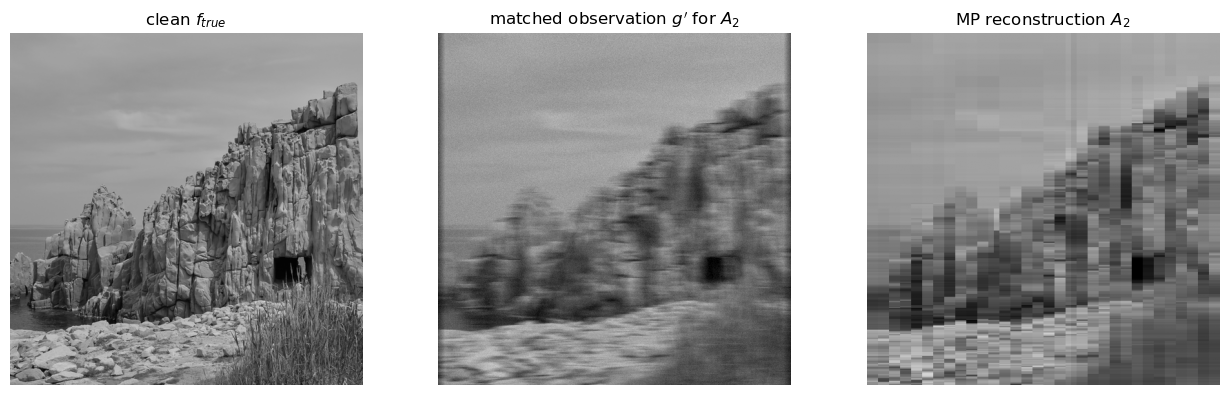

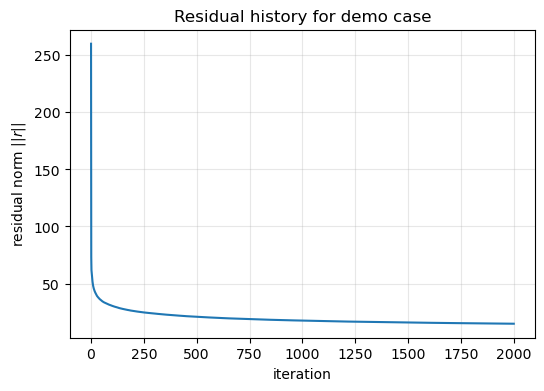

In [31]:
# 10. Visualize the full-size grayscale demonstration

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(f_true_demo, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("clean $f_{true}$")
axes[0].axis("off")

axes[1].imshow(gn_demo_A2, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("matched observation $g'$ for $A_2$")
axes[1].axis("off")

axes[2].imshow(np.clip(f_demo_A2, 0, 1), cmap="gray", vmin=0, vmax=1)
axes[2].set_title("MP reconstruction $A_2$")
axes[2].axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(r_demo_A2)
plt.xlabel("iteration")
plt.ylabel("residual norm $||r||$")
plt.title("Residual history for demo case")
plt.grid(alpha=0.3)
plt.show()


Matching Pursuit with a Haar basis recovers the coarse image structure, but with a small number of atoms it produces blocky, piecewise-constant reconstructions. Increasing the number of iterations improves detail but reduces sparsity and increases runtime.

## 5. All 3 images and 3 noise levels

The next cells run the main sparse method, `A_2`, for all three images and all three noise levels. This is now much faster than full RGB, but still uses the original 512 x 512 resolution.


In [32]:
# 11. Prepare all full-size grayscale matched observations for A_2

noise_levels_all = [0.02, 0.05, 0.10]
rng_sparse_all = np.random.default_rng(seed=20260629)
all_cases = []

for clean_id, clean_path in sorted(clean_paths.items()):
    f_true = load_gray_float(clean_path)

    for noise_level in noise_levels_all:
        noise = rng_sparse_all.normal(0.0, noise_level, size=f_true.shape)
        gn_A2 = np.clip(A_2_operator["forward"](f_true) + noise, 0.0, 1.0)

        all_cases.append(
            {
                "clean_id": clean_id,
                "noise_level": noise_level,
                "f_true": f_true,
                "gn_A2": gn_A2,
            }
        )

print(f"Prepared {len(all_cases)} full-size grayscale cases.")
for case in all_cases:
    print(f"image={case['clean_id']} | sigma={case['noise_level']:.2f} | shape={case['f_true'].shape}")


Prepared 9 full-size grayscale cases.
image=1 | sigma=0.02 | shape=(512, 512)
image=1 | sigma=0.05 | shape=(512, 512)
image=1 | sigma=0.10 | shape=(512, 512)
image=2 | sigma=0.02 | shape=(512, 512)
image=2 | sigma=0.05 | shape=(512, 512)
image=2 | sigma=0.10 | shape=(512, 512)
image=3 | sigma=0.02 | shape=(512, 512)
image=3 | sigma=0.05 | shape=(512, 512)
image=3 | sigma=0.10 | shape=(512, 512)


In [33]:
# 12. Run all full-size grayscale Matching Pursuit cases with A_2

N_ITER_ALL = N_ITER
all_results = []

for case_index, case in enumerate(all_cases, start=1):
    print(f"[{case_index}/{len(all_cases)}] image={case['clean_id']}, sigma={case['noise_level']:.2f}")

    start = time.perf_counter()
    f_A2, r_A2, s_A2 = solve_matching_pursuit_gray(A_2_operator, case["gn_A2"], N_ITER_ALL)
    time_A2 = time.perf_counter() - start

    all_results.append(
        {
            **case,
            "f_A2": f_A2,
            "r_A2": r_A2,
            "s_A2": s_A2,
            "time_A2": time_A2,
        }
    )

    print(f"  A_2 runtime: {time_A2:.1f}s, final ||r||={r_A2[-1]:.4f}")

print("Finished all full-size grayscale sparse Matching Pursuit cases.")


[1/9] image=1, sigma=0.02
A_2: zero padding in one dimension | iteration  100/2000: ||r|| = 30.511505
A_2: zero padding in one dimension | iteration  200/2000: ||r|| = 26.046063
A_2: zero padding in one dimension | iteration  300/2000: ||r|| = 23.750026
A_2: zero padding in one dimension | iteration  400/2000: ||r|| = 22.138821
A_2: zero padding in one dimension | iteration  500/2000: ||r|| = 20.915204
A_2: zero padding in one dimension | iteration  600/2000: ||r|| = 19.981260
A_2: zero padding in one dimension | iteration  700/2000: ||r|| = 19.167786
A_2: zero padding in one dimension | iteration  800/2000: ||r|| = 18.563877
A_2: zero padding in one dimension | iteration  900/2000: ||r|| = 18.022773
A_2: zero padding in one dimension | iteration 1000/2000: ||r|| = 17.544136
A_2: zero padding in one dimension | iteration 1100/2000: ||r|| = 17.160430
A_2: zero padding in one dimension | iteration 1200/2000: ||r|| = 16.792155
A_2: zero padding in one dimension | iteration 1300/2000: ||r|

In [34]:
# 13. Save all full-size grayscale sparse reconstructions

for result in all_results:
    clean_id = result["clean_id"]
    sigma = result["noise_level"]
    base = f"{clean_id}_full_gray_A2_matched_noise{sigma:.2f}_iter{N_ITER_ALL}"
    path_A2 = RESULTS_DIR / f"{base}_mp.png"
    save_gray_float(path_A2, result["f_A2"])
    result["path_A2"] = path_A2

print(f"Saved {len(all_results)} full-size grayscale reconstructions to {RESULTS_DIR.relative_to(PROJECT_ROOT)}")


Saved 9 full-size grayscale reconstructions to data/results/sparse_matching_pursuit


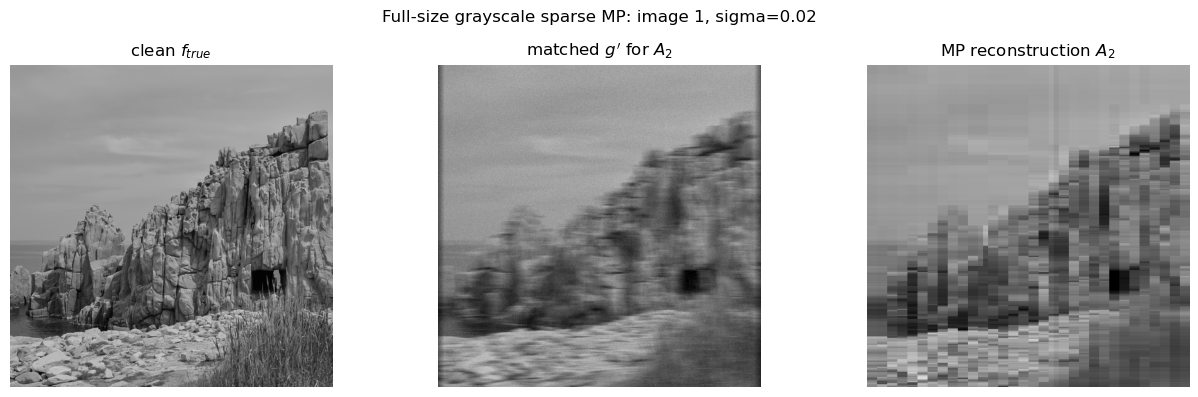

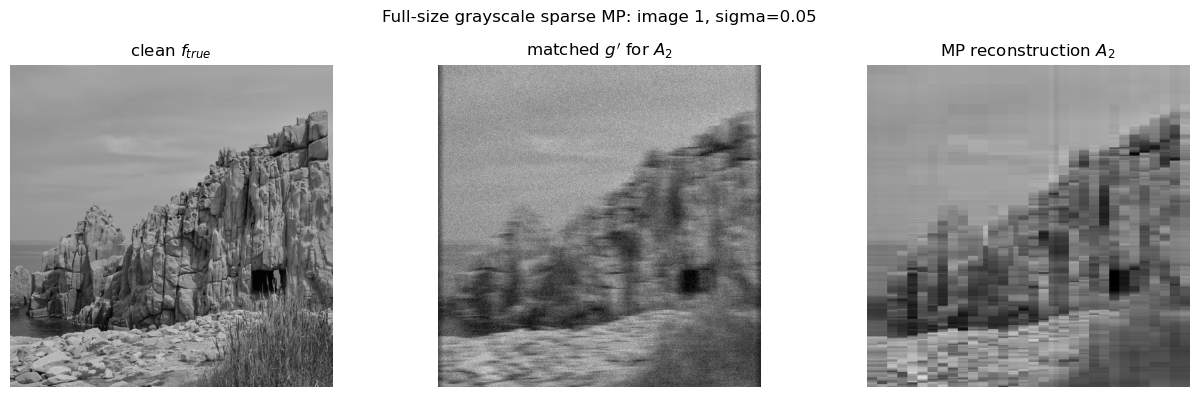

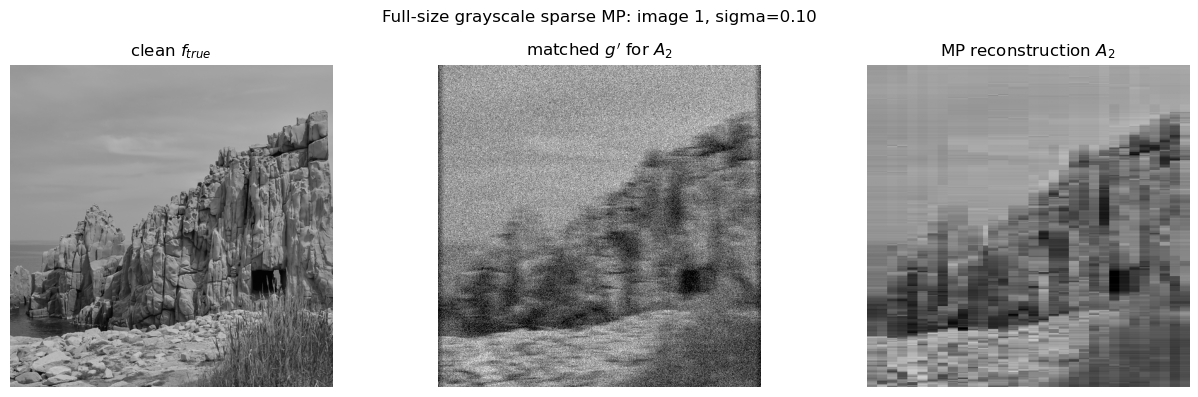

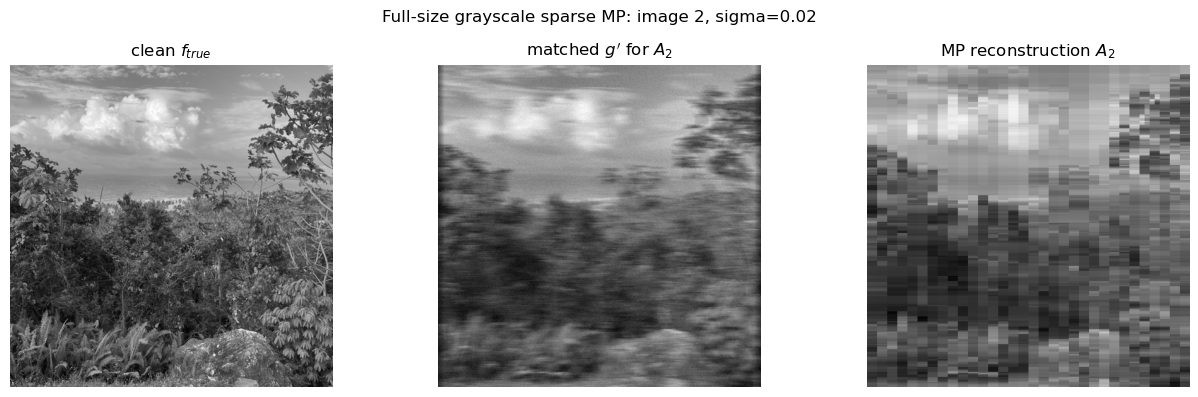

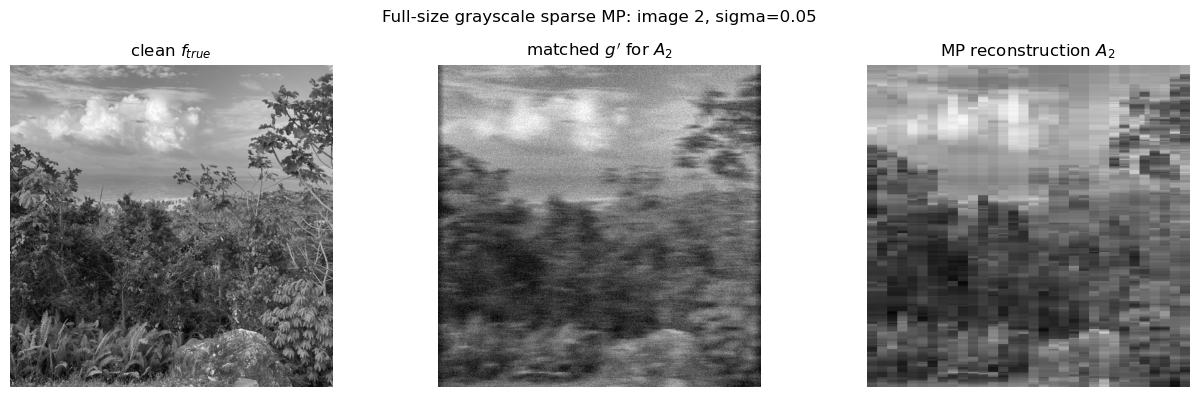

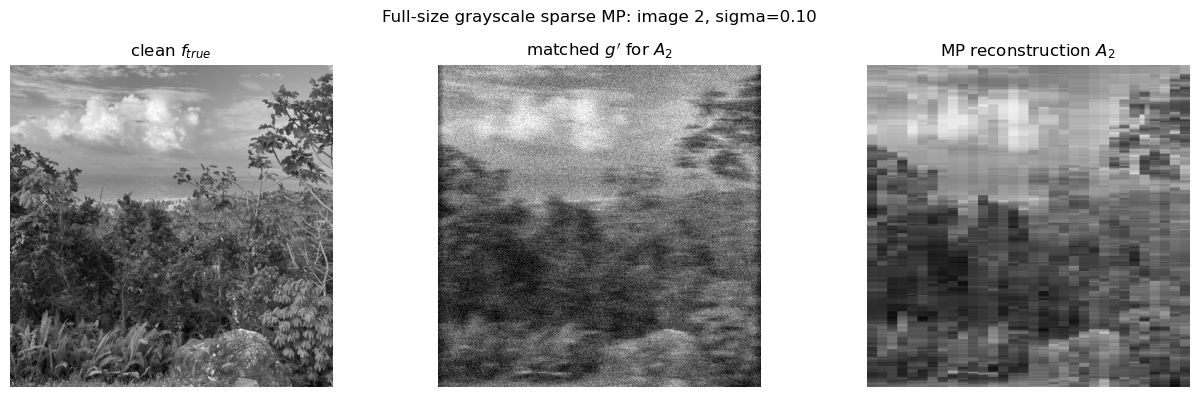

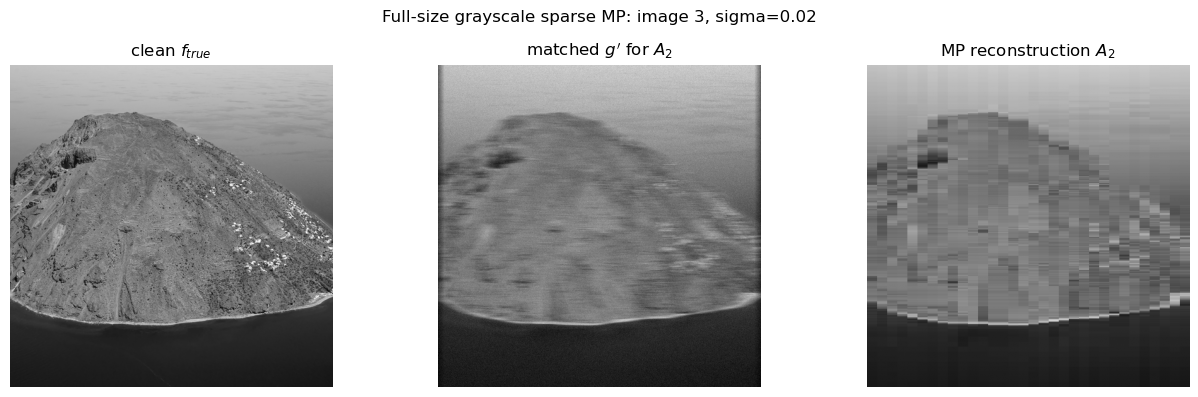

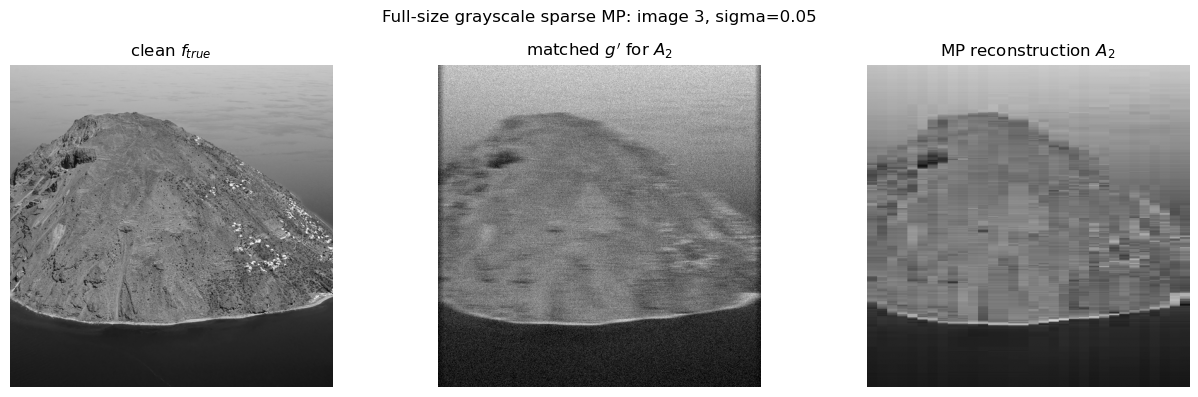

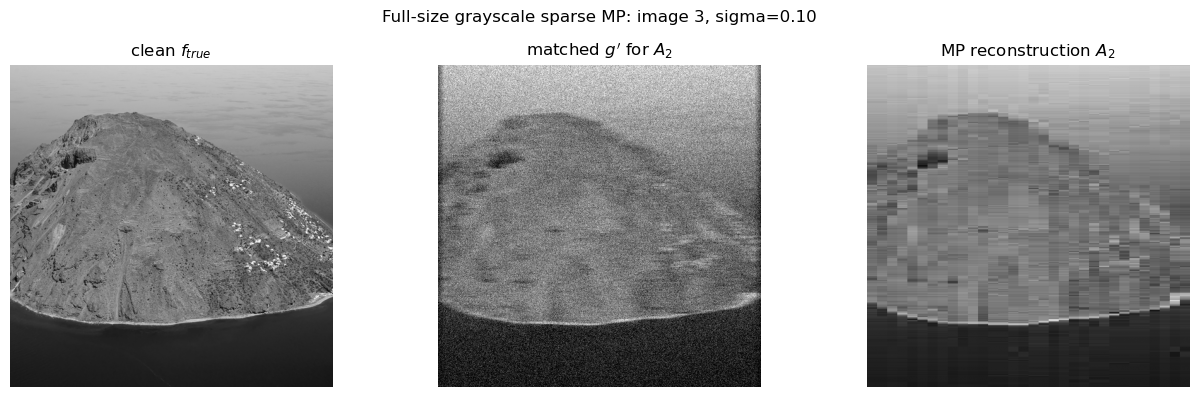

In [35]:
# 14. Visualize all full-size grayscale sparse reconstructions

for result in all_results:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].imshow(result["f_true"], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("clean $f_{true}$")
    axes[0].axis("off")

    axes[1].imshow(result["gn_A2"], cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("matched $g'$ for $A_2$")
    axes[1].axis("off")

    axes[2].imshow(np.clip(result["f_A2"], 0, 1), cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("MP reconstruction $A_2$")
    axes[2].axis("off")

    fig.suptitle(f"Full-size grayscale sparse MP: image {result['clean_id']}, sigma={result['noise_level']:.2f}")
    plt.tight_layout()
    plt.show()


In [36]:
# 15. Optional: compare A_1 and A_2 on one case only
# This cell is optional because A_1 roughly doubles runtime if used for all cases.

RUN_OPTIONAL_A1_COMPARISON = False

if RUN_OPTIONAL_A1_COMPARISON:
    start = time.perf_counter()
    gn_demo_A1 = np.clip(A_1_operator["forward"](f_true_demo) + noise_demo, 0.0, 1.0)
    f_demo_A1, r_demo_A1, s_demo_A1 = solve_matching_pursuit_gray(A_1_operator, gn_demo_A1, N_ITER)
    time_demo_A1 = time.perf_counter() - start

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(f_true_demo, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("clean $f_{true}$")
    axes[0].axis("off")
    axes[1].imshow(np.clip(f_demo_A1, 0, 1), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("MP reconstruction $A_1$")
    axes[1].axis("off")
    axes[2].imshow(np.abs(f_demo_A1 - f_demo_A2), cmap="inferno")
    axes[2].set_title("|$f_{A1}-f_{A2}$|")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

    print(f"A_1 optional runtime: {time_demo_A1:.1f}s")
else:
    print("Optional A_1 comparison skipped. Set RUN_OPTIONAL_A1_COMPARISON = True to run it.")


Optional A_1 comparison skipped. Set RUN_OPTIONAL_A1_COMPARISON = True to run it.


## 6. Interpretation

This notebook now uses full-size 512 x 512 images, but in grayscale for speed. This is a reasonable compromise: it keeps the original spatial resolution while reducing the Matching Pursuit search space by a factor of three compared with RGB.

The main result is the `A_2` sparse reconstruction. Since the motion blur is horizontal, the row-wise `A_2` operator is the natural sparse-method model from the exercise.

Matching Pursuit is still a greedy sparse method. Even with thousands of iterations, it selects only a tiny fraction of all possible Haar coefficients. Therefore the reconstruction may still be smoother or more blocky than Tikhonov or DPIR, but it demonstrates the required sparse wavelet approach.

For the report, we can say that the sparse method was evaluated on full-resolution grayscale images for computational feasibility, while the other methods can be run on full RGB images.
